In [1]:
%cd /content

!git clone https://github.com/Aishwarya-93/Deepfake-Detection-KYC.git

%cd Deepfake-Detection-KYC

/content
Cloning into 'Deepfake-Detection-KYC'...
remote: Enumerating objects: 211, done.
remote: Counting objects: 100% (211/211), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 211 (delta 108), reused 129 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (211/211), 3.64 MiB | 44.42 MiB/s, done.
Resolving deltas: 100% (108/108), done.
/content/Deepfake-Detection-KYC


In [2]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.13.0.92
Uninstalling opencv-contrib-python-4.13.0.92:
  Successfully uninstalled opencv-contrib-python-4.13.0.92
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 13.9 MB/s eta 0:00:00


In [3]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
True


# Lab 12 – PyTorch Dataset & DataLoader

## Objective

The objective of this lab is to load the processed face images generated in Lab 13 into PyTorch.

The processed dataset is organized as:

data/processed/
├── train/
│   ├── real/
│   └── fake/
├── val/
│   ├── real/
│   └── fake/
└── test/
    ├── real/
    └── fake/

This lab will:

1. Define the processed dataset paths.
2. Verify the processed images.
3. Create image transformations.
4. Load the reusable FaceDataset class.
5. Create train, validation and test DataLoaders.
6. Verify dataset and batch sizes.
7. Display sample processed faces.

The processed face dataset is generated by Lab 13.

In [22]:
from pathlib import Path

import torch
from torch.utils.data import DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt

from src.dataset.dataloader import FaceDataset

print("Libraries imported successfully.")

Libraries imported successfully.


In [23]:
print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("CUDA available: Yes")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("CUDA available: No")

PyTorch version: 2.11.0+cpu
CUDA available: No


In [24]:
PROJECT_ROOT = Path("/content/Deepfake-Detection-KYC")

DATASET_ROOT = PROJECT_ROOT / "data" / "processed"

TRAIN_DIR = DATASET_ROOT / "train"
VAL_DIR = DATASET_ROOT / "val"
TEST_DIR = DATASET_ROOT / "test"

print("Project Root:", PROJECT_ROOT)
print("Dataset Root:", DATASET_ROOT)
print("Train:", TRAIN_DIR)
print("Validation:", VAL_DIR)
print("Test:", TEST_DIR)

Project Root: /content/Deepfake-Detection-KYC
Dataset Root: /content/Deepfake-Detection-KYC/data/processed
Train: /content/Deepfake-Detection-KYC/data/processed/train
Validation: /content/Deepfake-Detection-KYC/data/processed/val
Test: /content/Deepfake-Detection-KYC/data/processed/test


In [25]:
required_directories = [
    TRAIN_DIR / "real",
    TRAIN_DIR / "fake",
    VAL_DIR / "real",
    VAL_DIR / "fake",
    TEST_DIR / "real",
    TEST_DIR / "fake"
]

print("Dataset directory verification:\n")

for directory in required_directories:
    status = "OK" if directory.exists() else "MISSING"
    print(f"{directory}: {status}")

Dataset directory verification:

/content/Deepfake-Detection-KYC/data/processed/train/real: OK
/content/Deepfake-Detection-KYC/data/processed/train/fake: OK
/content/Deepfake-Detection-KYC/data/processed/val/real: OK
/content/Deepfake-Detection-KYC/data/processed/val/fake: OK
/content/Deepfake-Detection-KYC/data/processed/test/real: OK
/content/Deepfake-Detection-KYC/data/processed/test/fake: OK


In [26]:
def count_images(directory):
    extensions = ["*.jpg", "*.jpeg", "*.png"]

    return sum(
        len(list(directory.glob(extension)))
        for extension in extensions
    )


print("Processed image counts:\n")

for split, directory in [
    ("Train", TRAIN_DIR),
    ("Validation", VAL_DIR),
    ("Test", TEST_DIR)
]:

    real_count = count_images(directory / "real")
    fake_count = count_images(directory / "fake")

    print(f"{split}:")
    print(f"  REAL: {real_count}")
    print(f"  FAKE: {fake_count}")
    print(f"  TOTAL: {real_count + fake_count}")
    print()

Processed image counts:

Train:
  REAL: 346
  FAKE: 390
  TOTAL: 736

Validation:
  REAL: 74
  FAKE: 64
  TOTAL: 138

Test:
  REAL: 64
  FAKE: 106
  TOTAL: 170



In [27]:
IMAGE_SIZE = (224, 224)

transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor()
])

print("Image size:", IMAGE_SIZE)
print("Transform pipeline created successfully.")

Image size: (224, 224)
Transform pipeline created successfully.


In [28]:
train_dataset = FaceDataset(
    TRAIN_DIR,
    transform=transform
)

val_dataset = FaceDataset(
    VAL_DIR,
    transform=transform
)

test_dataset = FaceDataset(
    TEST_DIR,
    transform=transform
)

print("FaceDataset objects created successfully.")

FaceDataset objects created successfully.


In [29]:
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))

Training images: 736
Validation images: 138
Testing images: 170


In [30]:
print("Class mapping:")
print("REAL = 0")
print("FAKE = 1")

Class mapping:
REAL = 0
FAKE = 1


In [31]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders created successfully.")
print("Batch size:", BATCH_SIZE)

DataLoaders created successfully.
Batch size: 8


In [32]:
print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

Training batches: 92
Validation batches: 18
Testing batches: 22


In [33]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)

print("\nLabels:")
print(labels)

Image batch shape: torch.Size([8, 3, 224, 224])
Labels shape: torch.Size([8])

Labels:
tensor([1, 0, 0, 0, 1, 0, 0, 0])


In [34]:
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())
print("Data type:", images.dtype)

Minimum pixel value: 0.0
Maximum pixel value: 1.0
Data type: torch.float32


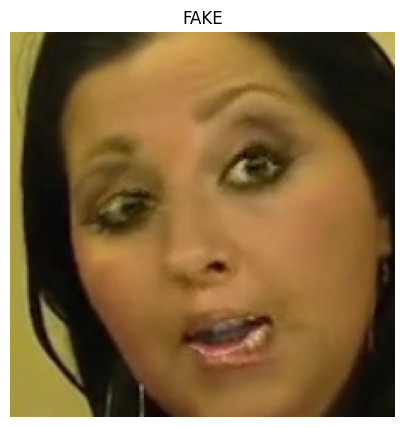

In [35]:
image = images[0].permute(1, 2, 0)
label = labels[0].item()

plt.figure(figsize=(5, 5))

plt.imshow(image)

plt.title(
    "FAKE" if label == 1 else "REAL"
)

plt.axis("off")
plt.show()

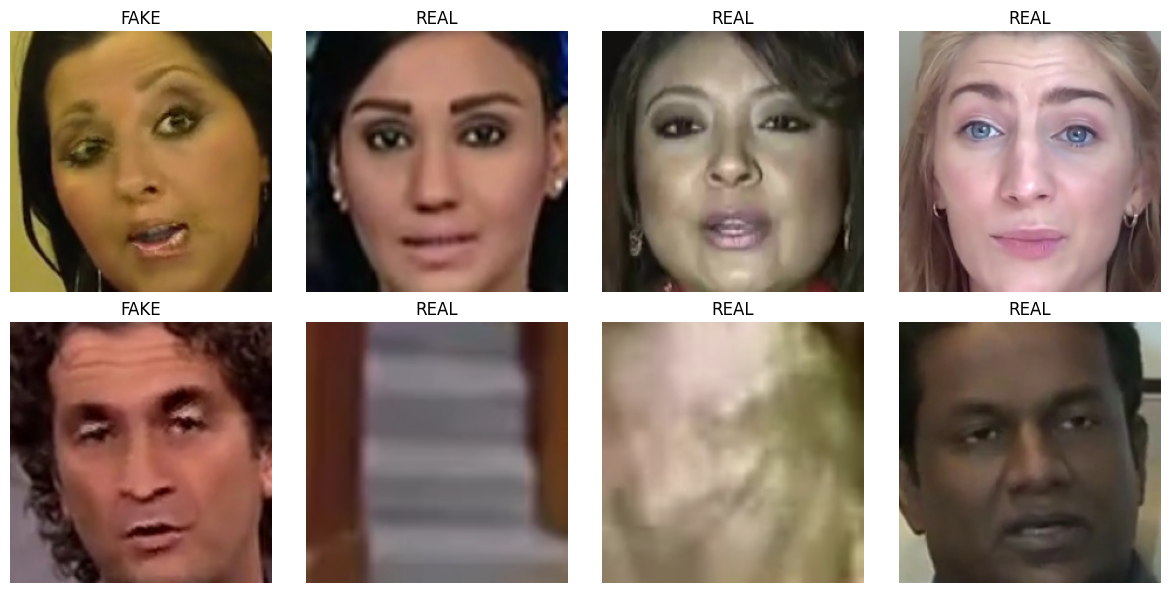

In [36]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1, 2, 0)
    label = labels[i].item()

    ax.imshow(image)

    ax.set_title(
        "FAKE" if label == 1 else "REAL"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [37]:
print("=" * 50)
print("LAB 12 FINAL VERIFICATION")
print("=" * 50)

print("Training dataset :", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Testing dataset  :", len(test_dataset))

print()

print("Training batches :", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches  :", len(test_loader))

print()

print("Batch shape:", images.shape)
print("Label shape:", labels.shape)

print()

print("PyTorch Dataset + DataLoader working successfully!")

LAB 12 FINAL VERIFICATION
Training dataset : 736
Validation dataset: 138
Testing dataset  : 170

Training batches : 92
Validation batches: 18
Testing batches  : 22

Batch shape: torch.Size([8, 3, 224, 224])
Label shape: torch.Size([8])

PyTorch Dataset + DataLoader working successfully!


## Conclusion

Lab 12 successfully loaded the processed face-image dataset generated in Lab 13 using PyTorch.

The `FaceDataset` class was used to load the REAL and FAKE face images.

Train, validation, and test DataLoaders were created successfully.

The DataLoader was verified by loading a batch of images and checking:

- Image tensor shape
- Label tensor shape
- Pixel value range
- Image data type
- Sample face visualization

The processed dataset is now ready for the model training phase.